## BES Rainfall Analysis Project Number: 26009003
Test Aquarius data downloader and gaps analysis
Jamie Feldman 
3/17/2026

In [69]:
%load_ext autoreload
%autoreload 2

import os
import pandas
import gauge_analysis
import matplotlib.pyplot as plt
from datetime import date
import storm_catalog
import regional_storm_analysis
import config
from logging_setup import setup_logging, get_logger
from data_loader import find_latest_database, load_rainfall_data, filter_by_date
from storm_catalog import StormCatalog

setup_logging()
logger = get_logger(__name__)

today = date.today()

from config import OUTPUT_DIR, START_DATE, END_DATE
OUTPUT_DIR

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'C:/Users/jfeldman/OneDrive - Geosyntec/BES_SPEC_MOD_ONCALL_TEAM - GC001_BES_Rainfall_Analysis_Task/Code/Outputs'

In [ ]:
# latest = gauge_analysis.find_latest_database(OUTPUT_DIR)
# all_data = gauge_analysis.load_rainfall_data(latest)

12:36:14 - INFO - Looking for database files in C:/Users/jfeldman/OneDrive - Geosyntec/BES_SPEC_MOD_ONCALL_TEAM - GC001_BES_Rainfall_Analysis_Task/Code/Outputs...
12:36:14 - INFO - Found 1 database file(s)
12:36:14 - INFO - Using database: C:/Users/jfeldman/OneDrive - Geosyntec/BES_SPEC_MOD_ONCALL_TEAM - GC001_BES_Rainfall_Analysis_Task/Code/Outputs\precipitation_15min_downloaded_2026-03-11.db
12:36:14 - INFO - Loading data from database
12:36:41 - INFO - Loaded 17,633,712 rows from database
12:37:08 - INFO -   Example: 1976-04-01 00:10:00-08:00 -> 1976-04-01 00:15:00-08:00
12:37:08 - INFO - Pivoting to wide format
12:37:14 - INFO - Result: 1,751,178 timestamps x 11 gauges
12:37:14 - INFO - gauges: HYDRA-1, HYDRA-10, HYDRA-12, HYDRA-14, HYDRA-145...


In [ ]:
# all_data

location,HYDRA-1,HYDRA-10,HYDRA-12,HYDRA-14,HYDRA-145,HYDRA-153,HYDRA-2,HYDRA-3,HYDRA-4,HYDRA-58,HYDRA-6
timestamp_aligned,,,,,,,,,,,
1976-04-01 00:15:00-08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1976-04-01 00:30:00-08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1976-04-01 00:45:00-08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1976-04-01 01:00:00-08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1976-04-01 01:15:00-08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-11 12:30:00-08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.01
2026-03-11 12:45:00-08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.02
2026-03-11 13:00:00-08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.03


16:26:41 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
16:26:41 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
16:26:41 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
16:26:41 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\jfeldman\\miniforge3\\envs\\bes_aquarius\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizThreeSymBol.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
16:26:41 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\jfeldman\\miniforge3\\envs\\bes_aquarius\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizThreeSymReg.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
16:26:41 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\jfeldman\\miniforge3\\envs\\bes_aq

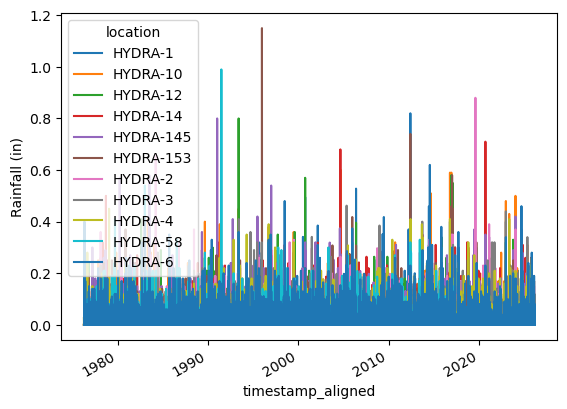

In [ ]:
# ax = all_data.plot(ylabel='Rainfall (in)')
# ax.get_figure().savefig(os.path.join(OUTPUT_DIR, '15-min_Rainfall_'+str(today)+'.png'))

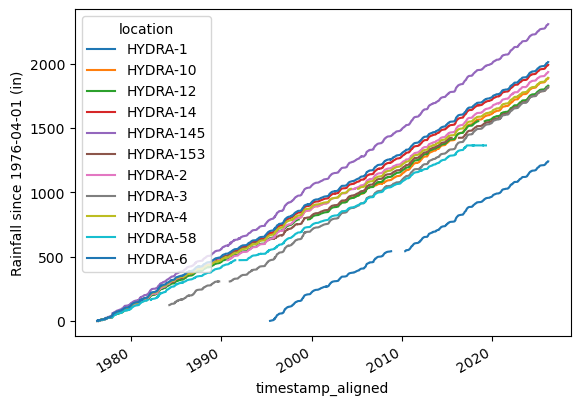

In [ ]:
# cumsum = all_data.cumsum().plot(ylabel='Rainfall since 1976-04-01 (in)')
# cumsum.get_figure().savefig(os.path.join(OUTPUT_DIR, 'Cumulative_Sum_'+str(today)+'.png'))

In [ ]:
# gauge_analysis.investigate_true_missingness(all_data)


gauge        Started                Total After  Missing      % Missing 
----------------------------------------------------------------------
HYDRA-1      1995-05-18 13:30:00    1,080,469    54,680       5.1       %
HYDRA-10     1976-04-02 00:00:00    1,751,083    117,523      6.7       %
HYDRA-12     1976-04-02 00:00:00    1,751,083    66,532       3.8       %
HYDRA-14     1976-04-02 00:00:00    1,751,083    13,622       0.8       %
HYDRA-145    1976-04-30 08:45:00    1,748,360    14,542       0.8       %
HYDRA-153    1976-04-02 00:00:00    1,751,083    66,260       3.8       %
HYDRA-2      1976-05-26 10:45:00    1,745,856    63,964       3.7       %
HYDRA-3      1976-05-26 14:30:00    1,745,841    196,592      11.3      %
HYDRA-4      1976-04-01 00:15:00    1,751,178    37,973       2.2       %
HYDRA-58     1976-05-21 15:45:00    1,746,316    298,266      17.1      %
HYDRA-6      1976-04-02 00:00:00    1,751,083    10,395       0.6       %


In [ ]:
# all_data['HYDRA-4'].isna().sum()/1751178

In [ ]:
# len(all_data)

In [ ]:
# gauge_analysis.analyze_gage_coobservation(all_data, 'HYDRA-4')

In [ ]:
# gauge_analysis.analyze_all_gauges(all_data)

In [ ]:
# gauge_analysis.save_results(gauge_analysis.analyze_all_gauges(all_data), data_path)

In [2]:

db_path = find_latest_database(OUTPUT_DIR)
logger.info(f"Using database: {db_path}")

if db_path is None:
    logger.error("Cannot continue without a database file")
    
# Load into DataFrame
rain_df = load_rainfall_data(db_path)

# Limit dates
rain_df = filter_by_date(rain_df, START_DATE, END_DATE)

logger.info(f"Loaded {len(rain_df):,} timestamps, {len(rain_df.columns)} gauges")

13:35:42 - INFO - Looking for database files in C:/Users/jfeldman/OneDrive - Geosyntec/BES_SPEC_MOD_ONCALL_TEAM - GC001_BES_Rainfall_Analysis_Task/Code/Outputs...
13:35:42 - INFO - Found 1 database file(s)
13:35:42 - INFO - Using database: C:/Users/jfeldman/OneDrive - Geosyntec/BES_SPEC_MOD_ONCALL_TEAM - GC001_BES_Rainfall_Analysis_Task/Code/Outputs\precipitation_15min_downloaded_2026-03-11.db
13:35:42 - INFO - Using database: C:/Users/jfeldman/OneDrive - Geosyntec/BES_SPEC_MOD_ONCALL_TEAM - GC001_BES_Rainfall_Analysis_Task/Code/Outputs\precipitation_15min_downloaded_2026-03-11.db
13:35:42 - INFO - Loading data from database
13:36:10 - INFO - Loaded 17,633,712 rows from database
13:36:34 - INFO -   Example: 1976-04-01 00:10:00-08:00 -> 1976-04-01 00:15:00-08:00
13:36:34 - INFO - Pivoting to wide format
13:36:39 - INFO - Result: 1,751,178 timestamps x 11 gauges
13:36:39 - INFO - gauges: HYDRA-1, HYDRA-10, HYDRA-12, HYDRA-14, HYDRA-145...
13:36:40 - INFO - Filtered to 1980-01-01 to 2010-

In [72]:
### Find Storms
min_gauges = 3
interevent_hours = 6

catalog = StormCatalog(
    rain_df,
    min_gauges= min_gauges,
    interevent_hours= interevent_hours
)
catalog.find_storms()


14:54:55 - INFO -   Rain Threshold: 0.0
14:54:55 - INFO -   Min Gauges: 3
14:54:55 - INFO -   In-storm timestamps: 251,823
14:54:55 - INFO -   Storms Identified: 4,089
14:54:55 - INFO -   Creating Storm Objects...
14:54:56 - INFO -     Created 1,000 storms...
14:54:57 - INFO -     Created 2,000 storms...
14:54:57 - INFO -     Created 3,000 storms...
14:54:58 - INFO -     Created 4,000 storms...
14:54:58 - INFO -     Created 4,089 storms...


In [44]:
# Export
catalog.to_csv(OUTPUT_DIR)
logger.info("Analysis complete!")

14:24:58 - INFO - Saved 4089 storms to C:/Users/jfeldman/OneDrive - Geosyntec/BES_SPEC_MOD_ONCALL_TEAM - GC001_BES_Rainfall_Analysis_Task/Code/Outputs\storm_catalog_inteventhr6_mingauges3_2026-03-29.csv
14:24:58 - INFO - Analysis complete!


In [63]:
# Report
print(f"\n{'='*75}")
print("REGIONAL STORM ANALYSIS")
print(f"{'='*75}")
print(f"Total storms: {catalog.n_storms:,}")

print("\n--- Top 10 Largest Storms ---")
print(f"{'Storm':<8} {'Date':<12} {'Hours':<8} {'Mean Rain':<10} {'Max Rain':<10}")
print("-" * 55)

for storm in catalog.get_largest_storms(10, by='max_gauge_rain'):
    print(f"{storm.number:<8} "
            f"{storm.start_time.strftime('%Y-%m-%d'):<12} "
            f"{storm.duration_hours:<8.1f} "
            f"{storm.mean_gauge_rain:<10.3f} "
            f"{storm.max_gauge_rain:<10.3f}")
    
print("\n--- Top 10 Most Intense Storms (rain per hour) ---")
print(f"{'Storm':<8} {'Date':<12} {'Hours':<8} {'Max Rain':<10} {'Intensity':<10}")
print("-" * 55)

for storm in catalog.get_largest_storms(10, by='peak_intensity'):
    print(f"{storm.number:<8} "
        f"{storm.start_time.strftime('%Y-%m-%d'):<12} "
        f"{storm.duration_hours:<8.1f} "
        f"{storm.max_gauge_rain:<10.3f} "
        f"{storm.peak_intensity:<10.3f}")



REGIONAL STORM ANALYSIS
Total storms: 4,089

--- Top 10 Largest Storms ---
Storm    Date         Hours    Mean Rain  Max Rain  
-------------------------------------------------------
2079     1996-02-05   95.0     6.496      7.790     
1904     1994-10-26   50.2     3.601      6.110     
3634     2007-12-01   73.0     4.323      5.698     
3486     2006-11-05   62.8     4.682      5.610     
3283     2005-03-26   88.0     3.373      4.895     
2188     1996-11-17   66.2     3.417      4.680     
121      1980-12-01   54.5     2.990      4.540     
1906     1994-10-30   55.5     2.751      4.170     
1839     1994-02-22   63.0     2.607      4.110     
106      1980-11-06   80.8     2.584      4.050     

--- Top 10 Most Intense Storms (rain per hour) ---
Storm    Date         Hours    Max Rain   Intensity 
-------------------------------------------------------
2061     1995-12-18   5.8      1.150      1.150     
1527     1991-06-19   41.0     2.720      0.990     
1746     1993-05-1

In [76]:
gap_summary = pandas.DataFrame()
for storm in catalog.get_largest_storms(10, by='max_gauge_rain'):
    storm_info = pandas.DataFrame(storm.gauge_missing.rename(storm.start_time).to_frame().T)
    storm_info = storm_info.assign(Max_Depth = storm.max_gauge_rain)
    storm_info = storm_info.assign(Peak_Int = storm.peak_intensity)
    gap_summary = pandas.concat([gap_summary, storm_info], axis = 0)
for storm in catalog.get_largest_storms(10, by='peak_intensity'):
    storm_info = pandas.DataFrame(storm.gauge_missing.rename(storm.start_time).to_frame().T)
    storm_info = storm_info.assign(Max_Depth = storm.max_gauge_rain)
    storm_info = storm_info.assign(Peak_Int = storm.peak_intensity)
    gap_summary = pandas.concat([gap_summary, storm_info], axis = 0)
gap_summary = gap_summary.round(1).sort_index()
gap_summary.to_csv(os.path.join(OUTPUT_DIR, f"large_storm_gaps_inteventhr{interevent_hours}_mingauges{min_gauges}_{today}.csv"))
gap_summary

location,HYDRA-1,HYDRA-10,HYDRA-12,HYDRA-14,HYDRA-145,HYDRA-153,HYDRA-2,HYDRA-3,HYDRA-4,HYDRA-58,HYDRA-6,Max_Depth,Peak_Int
1980-03-17 02:30:00-08:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.3,0.6
1980-11-06 09:15:00-08:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.1,0.4
1980-12-01 22:15:00-08:00,1.0,0.0,0.0,0.0,0.0,0.0,0.1,1.0,0.0,0.0,0.0,4.5,0.3
1982-12-31 11:15:00-08:00,1.0,0.0,0.0,0.0,0.0,0.2,0.0,1.0,0.0,0.0,0.0,1.0,0.5
1983-06-29 13:15:00-08:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.8,0.6
1984-03-14 13:45:00-08:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.6,0.7
1991-06-19 18:45:00-08:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.7,1.0
1993-05-19 14:30:00-08:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.3,0.8
1994-02-22 22:30:00-08:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.0,4.1,0.2
1994-10-26 10:30:00-08:00,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,6.1,0.2


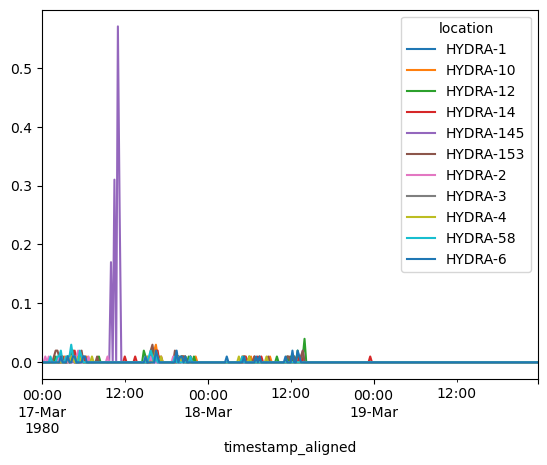

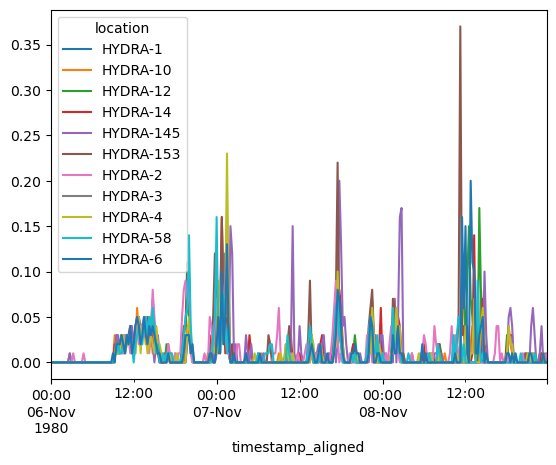

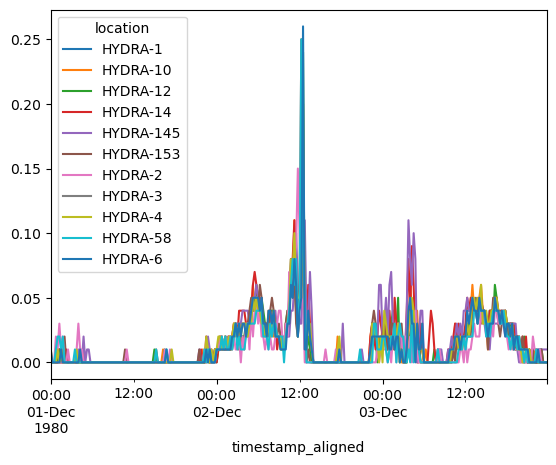

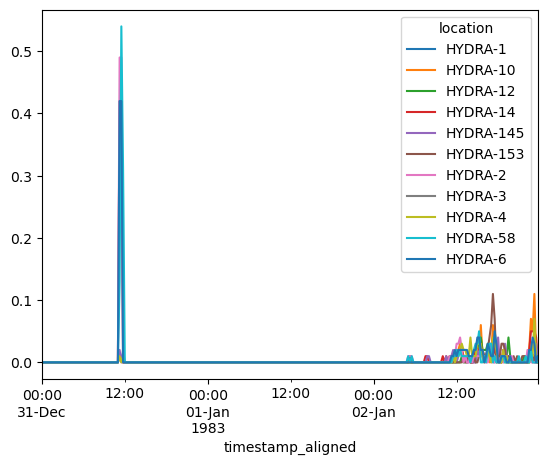

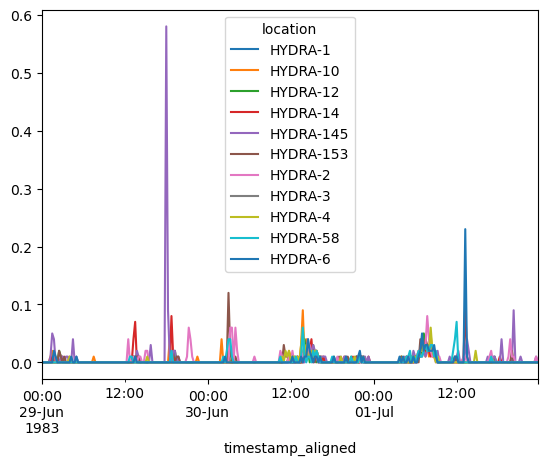

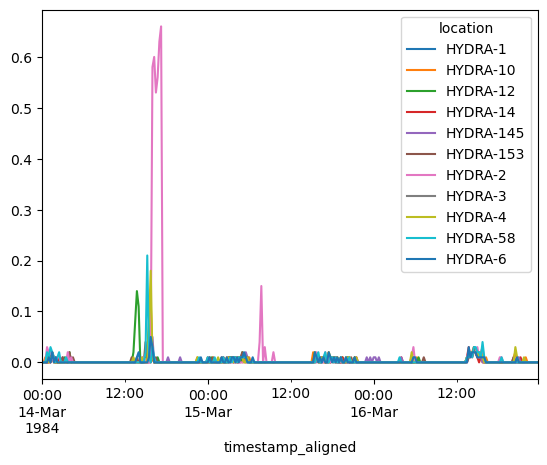

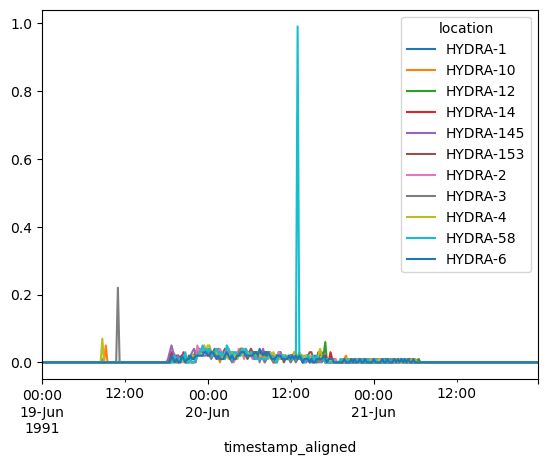

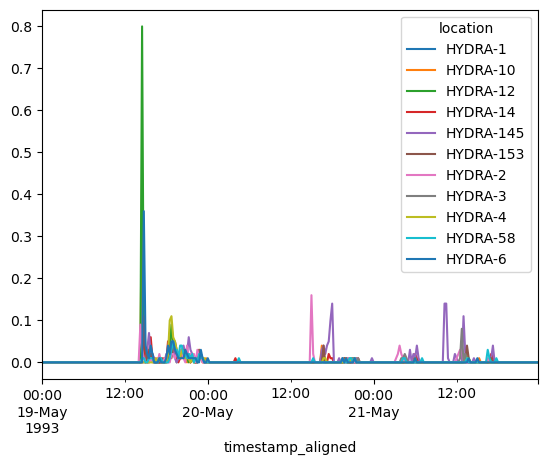

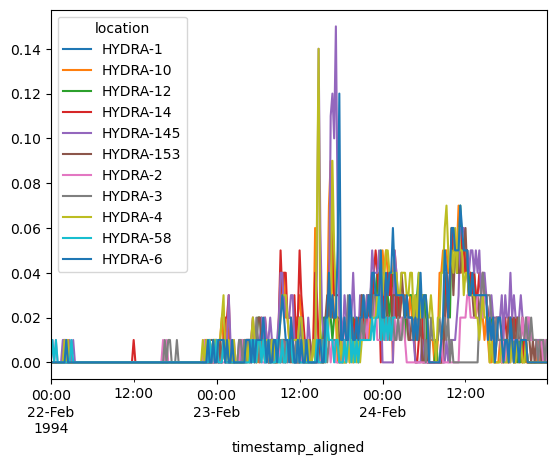

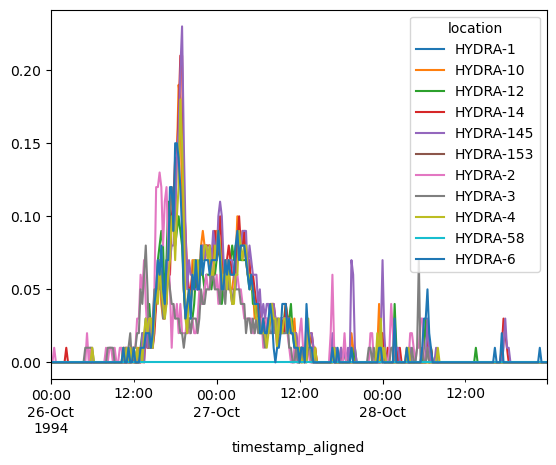

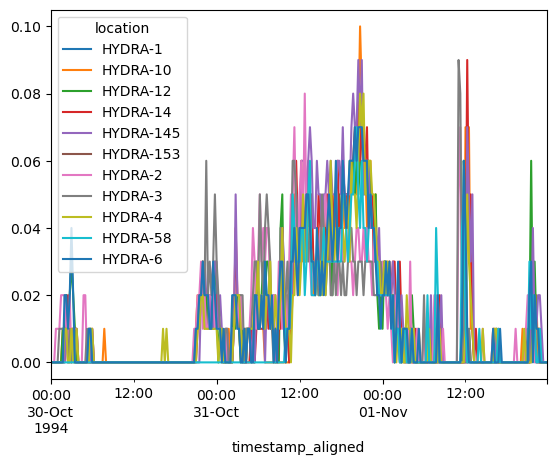

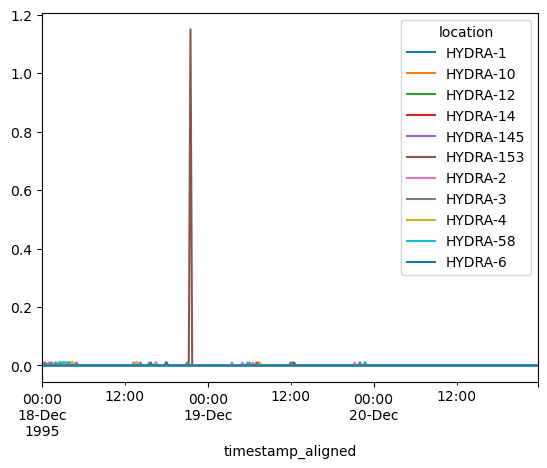

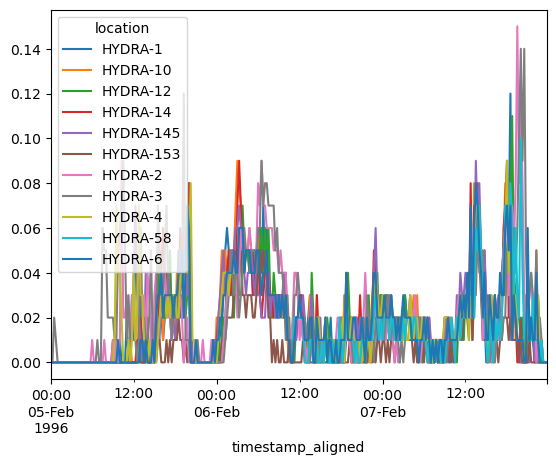

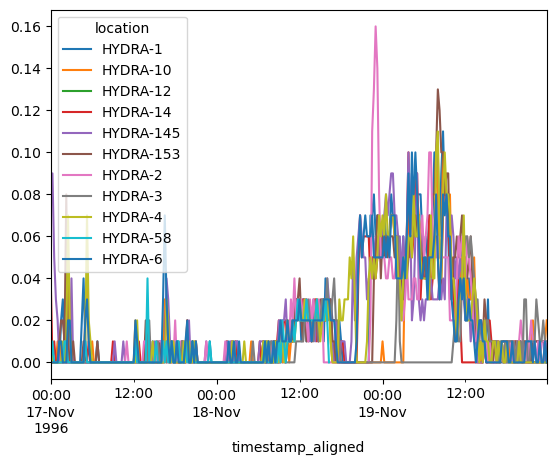

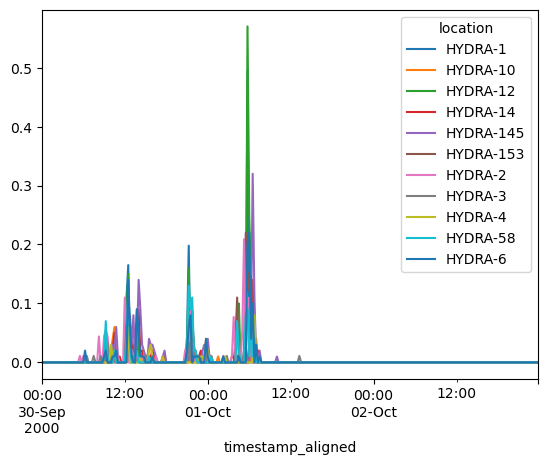

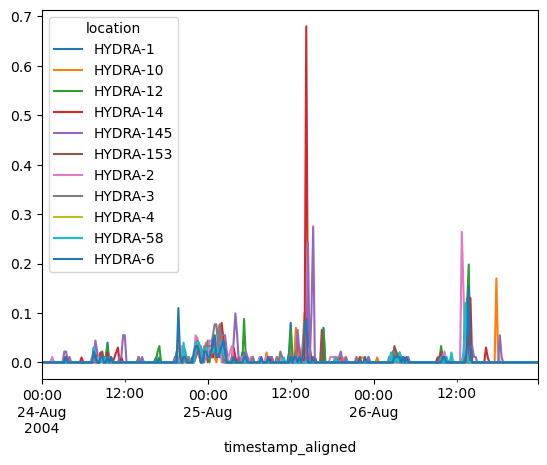

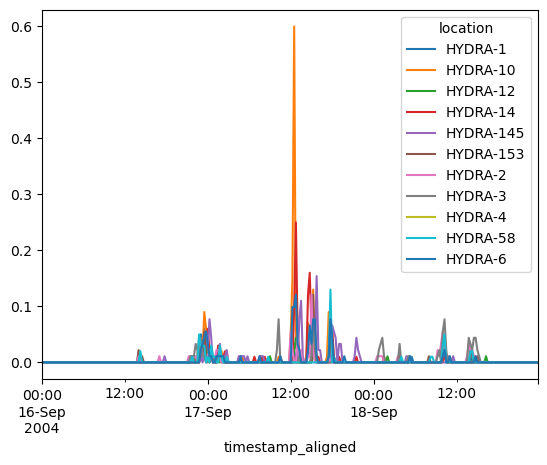

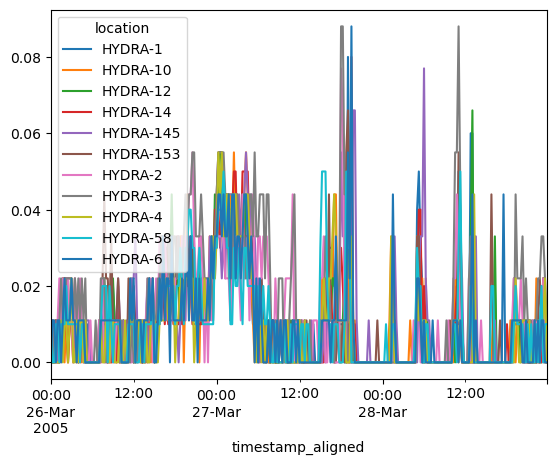

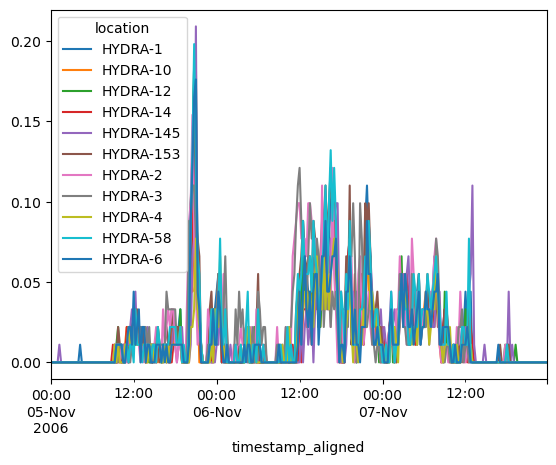

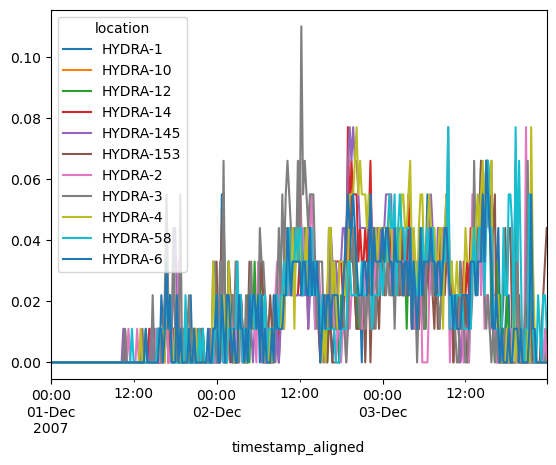

In [77]:
for date in gap_summary.index:
    rain_df.loc[date.strftime("%Y-%m-%d"):(date+pandas.Timedelta(days=2)).strftime("%Y-%m-%d")].plot()